# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Matthias van Weeren
* Username: mbweeren
* Student number: s6457002
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

We are given that $$g = \frac{4\pi^2L}{T^2}$$. The partial derivatives of this function are: $$\frac{\partial g}{\partial L} = \frac{4\pi^2}{T^2}$$ and $$\frac{\partial g}{\partial T} = -\frac{8\pi^2L}{T^3}$$. Now using $\sigma_L = 0.01$ and $\sigma_T = 0.02$ and substituting the values of L and T into the partial derivatives, we get that: $$\sigma_g = \sqrt{\left( \frac{4\pi^2}{2.01^2} \right)^2 \cdot 0.01^2 + \left( -\frac{8\pi^2 \cdot 1.00}{2.01^3} \right) ^2 \cdot 0.02^2} \approx 0.3$$. This gives us: $$g \approx 9.8 \pm \, 0.03 \, \text{m s}^{-2}$$

In [2]:
import numpy as np

#Classical error propagation:
#Given values
L_mean = 1.00
L_std = 0.01
T_mean = 2.01
T_std = 0.02

#Given formula
g = 4 * (np.pi**2) * L_mean / (T_mean**2)

#Partial derivatives
pdL = g / L_mean
pdT= -2 *g / T_mean


#error in g:
sigma_g = np.sqrt(pdL**2*L_std**2+pdT**2*T_std**2)

print(f"Classical error propagation gives g = {g:.1f} ± {sigma_g:.1f} m s\u207b\u00b2.")


#Monte Carlo erro propagation:
#Amount of samples:
n = 1000

#creating normal distributions for L and T (and g):
L_samples = np.random.normal(L_mean, L_std, n)
T_samples = np.random.normal(T_mean, T_std, n)

g_samples = 4 * (np.pi**2) * L_samples / (T_samples**2)

#Calculating the mean and standard deviation of g:
g_mean = np.mean(g_samples)
g_std = np.std(g_samples)

print(f"Monte Carlo error propagation gives g = {g_mean:.1f} ± {g_std:.1f} m s\u207b\u00b2.")

Classical error propagation gives g = 9.8 ± 0.2 m s⁻².
Monte Carlo error propagation gives g = 9.8 ± 0.2 m s⁻².


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
#Users input
a = float(input("Enter a: "))
b = float(input("Enter b: "))
c = float(input("Enter c: "))

print()
print(f"The resulting function is: f(x)  = {a}x\u00b2 + {b}x + {c}.")

#Calculation of discriminant:
D = b**2 - 4*a*c

#
if D >= 0:
    #Standard real roots
    sqrt_D = disc**0.5
    x1 = (-b + sqrt_D) / (2 * a)
    x2 = (-b - sqrt_D) / (2 * a)
else:
    #Complex roots: x = real_part +/- imaginary_part*j
    real_part = -b / (2 * a)
    imag_part = (abs(D)**0.5) / (2 * a)
    
    #Creating complex objects so that it becomes clear in the print command which value is the complex value:
    x1 = complex(real_part, imag_part)
    x2 = complex(real_part, -imag_part)

print(f"The two solutions to f(x) = 0 are x = {x1:.3f} or x = {x2:.3f}.")

#Proof that f(x) = 0:
print(f"Substituting these equations back into the chosen formula gives: f(x1) = {a*x1**2 + b*x1 + c:.2f} f(x2) = {a*x2**2 + b*x2 + c:.2f}")

Enter a: 2
Enter b: 1
Enter c: 3

The resulting function is: f(x)  = 2.0x² + 1.0x + 3.0.
The two solutions to f(x) = 0 are x = -0.250+1.199j or x = -0.250-1.199j.
Substituting these equations back into the chosen formula gives: f(x1) = 0.00+0.00j f(x2) = 0.00+0.00j


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

The area between x = 0 and x = 2.5 is (1.9769788548675902, 2.1948874438710744e-14).


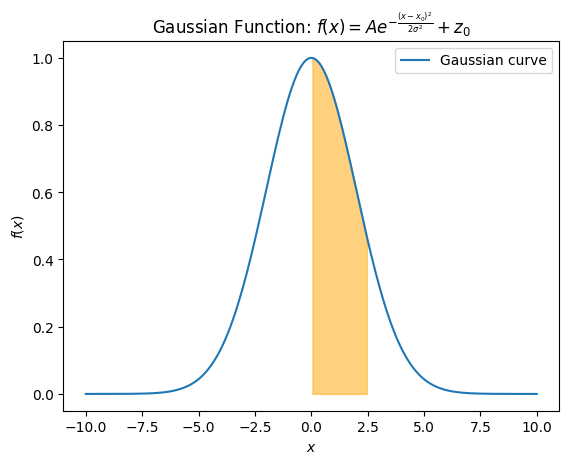

The area between x = -infinity and x = infinity is (5.013256549262001, 6.333282352159531e-09).
Using the given formula, we get that the area between x = -infinity and x = infinity is (5.013256549262001, 6.333282352159531e-09).
Thus bot methods indeed yield the same answer for the area under the curve.


In [6]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import integrate

#Given formula and values:
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0

#defining the conditions for the plot:
x = np.linspace(-10, 10, 200)
y = gauss(x, A, x0, sig, z0)

#Plotting the curve
plt.plot(x, y, label='Gaussian curve')
plt.title(rf"Gaussian Function: $f(x) = A e^{{ -\frac{{(x-x_0)^2}}{{2\sigma^2}} }} + z_0$")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend()

#Setting integration boundaries and integration:
a = 0
b = 2.5
integral = integrate.quad(gauss, a, b, args=(A, x0, sig, z0))
print(f"The area between x = 0 and x = 2.5 is {integral}.")

#Marking the integrated area:
plt.fill_between(x, y, where=(x >= 0) & (x <= 2.5), color='orange', alpha=0.5,label='Integrated Area')
plt.show()

#Calculating the area between -infinity and infinity:
c = -np.inf
d = np.inf
inf_int = integrate.quad(gauss, c, d, args=(A, x0, sig, z0))
print(f"The area between x = -infinity and x = infinity is {inf_int}.")

#Calculating the area using the given formula:
total_area = A * sig * np.sqrt(2 * np.pi)
print(f"Using the given formula, we get that the area between x = -infinity and x = infinity is {inf_int}.")
print(f"Thus bot methods indeed yield the same answer for the area under the curve.")

The following code can also be downloaded as an executable python script via my Github page: https://github.com/MBcodingW/PROGNUM-repo

Input a value for the amplitude A: 1
Input a value for the the position of the peak x0: 0
Input a value for the width of the peak sigma: 2
Input a value for the offset in y: 0
Input a value for the first integration limit a: 0
Input a value for the second integration limit b: 2.5
The area between x = 0.0 and x = 2.5 is (1.9769788548675902, 2.1948874438710744e-14).


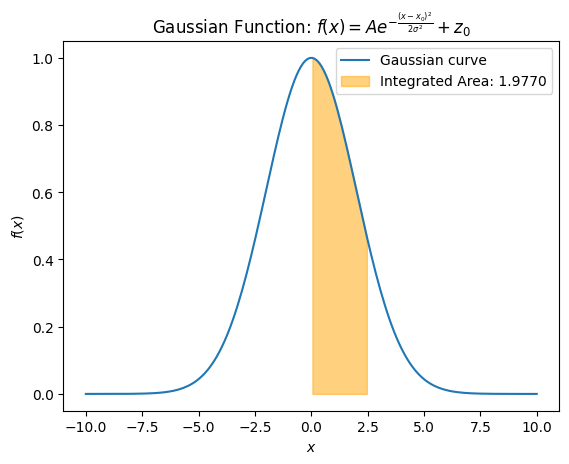

In [7]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import integrate

#Given formula:
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

#Input values:
A = float(input(f"Input a value for the amplitude A: "))
x0 = float(input(f"Input a value for the the position of the peak x0: "))
sig = float(input(f"Input a value for the width of the peak sigma: "))
z0 = float(input(f"Input a value for the offset in y: "))

#Input of integration limits and integration of the curve:
a = float(input(f"Input a value for the first integration limit a: "))
b = float(input(f"Input a value for the second integration limit b: "))
integral = integrate.quad(gauss, a, b, args=(A, x0, sig, z0))
print(f"The area between x = {a} and x = {b} is {integral}.")
          
#Plotting the curve:
plt.plot(x, y, label='Gaussian curve')
plt.title(rf"Gaussian Function: $f(x) = A e^{{ -\frac{{(x-x_0)^2}}{{2\sigma^2}} }} + z_0$")
plt.fill_between(x, y, where=(x >= a) & (x <= b), color='orange', alpha=0.5,label=f'Integrated Area: {integral[0]:.4f}')
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend()
plt.show()

In [8]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [9]:
import numpy as np
from numpy import sin, cos, exp, pi
from scipy import integrate

try:
    #Input function:
    #(x**4 + exp(sin(x)+cos(x)))
    user_input = input("Input a function of x: ")
    fun = lambda x: eval(user_input)

    #Integration limits:
    a = eval((input("Input a value for the first integration limit a: ")))
    b = eval((input("Input a value for the second integration limit b: ")))

    #Standard integral calculation
    st_int, error = integrate.quad(fun, a, b)
    print(f"\nUsing standard integration we get: {st_int:.6f}")

    #Monte Carlo integration
    n = 10000
    x_rand = np.random.uniform(a, b, n) 
    y = fun(x_rand)
    mc_int = (b - a) / n * np.sum(y)
    print(f"Using Monte Carlo integration we get: {mc_int:.6f}")

#Possible errors:
except SyntaxError:
    print("\n[Error] Wrong Expression: Check your math syntax.")
except NameError as e:
    print(f"\n[Error] Unknown Function or Variable: {e}")
    print("You can only use the functions 'x', 'sin', 'cos', 'exp', or 'pi'.")

except ValueError:
    print("\n[Error] Invalid Input: The integration limits must be (real) numbers.")

except ZeroDivisionError:
    print("\n[Error] Math Error: The function tried to divide by zero during calculation.")

except Exception as e:
    print(f"\n[Error] An unexpected error occurred: {e}")

Input a function of x: x**4 + exp(sin(x)+cos(x))
Input a value for the first integration limit a: 0
Input a value for the second integration limit b: pi

Using standard integration we get: 68.729323
Using Monte Carlo integration we get: 69.267057


An example of an error:

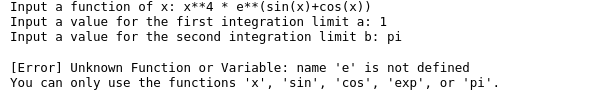

In [10]:
import sympy as sp

#Defining the function
x = sp.Symbol('x')
function = x**4 + sp.exp(sp.sin(x) + sp.cos(x))

#Integrating the function
integral = sp.integrate(function, (x, 0, sp.pi))
#Converting this integral using evalf() so the program print the actual value:
I = integral.evalf()

print(f"Using sympy we get an area of: {I}.")
print(sp.integrate(x**4 + sp.exp(sp.sin(x) + sp.cos(x)), (x, 0, sp.pi)).evalf())

Using sympy we get an area of: 68.7293227268911.
68.7293227268911


In [11]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

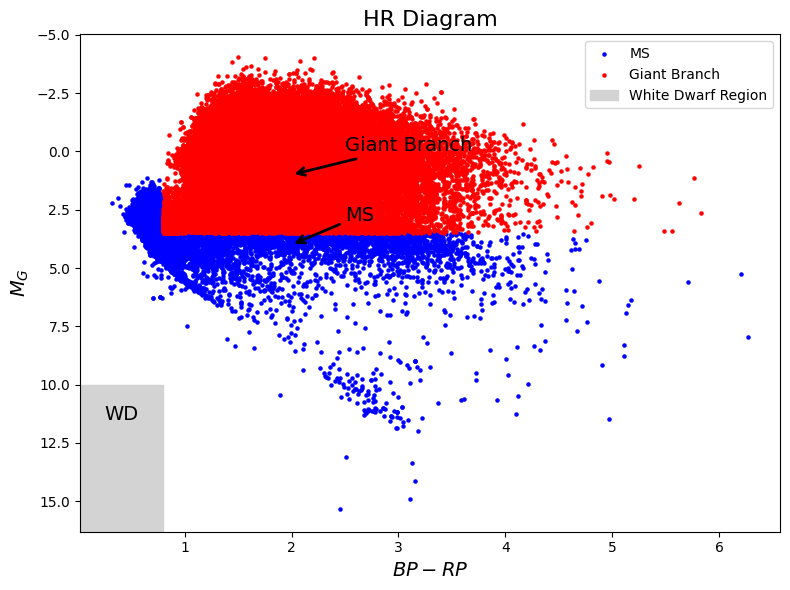

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

#Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data

#Mask filters the specified data from the file to match the conditions of the question:
mask = (data['STARFLAG'] == 0) & \
       (data['ASPCAPFLAG'] == 0) & \
       (data['SNR'] > 10) & \
       (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) & \
       (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) & \
       (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) & \
       (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))

#Filtered data
filtered_data = data[mask]

#Randomly select 80% of the data
n_samples = int(0.8 * len(filtered_data))
indices = np.random.choice(len(filtered_data), n_samples, replace=False)
selected_data = filtered_data[indices]

#Calculating the absolute magnitude, which correpsonds to the brightness of a star:
mg_apparent = selected_data['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = selected_data['GAIAEDR3_PARALLAX']
bp_rp = selected_data['GAIAEDR3_PHOT_BP_MEAN_MAG'] - selected_data['GAIAEDR3_PHOT_RP_MEAN_MAG']

#Formula: M_G = m_G + 5 * log10(parallax/1000) + 5
MG_absolute = mg_apparent + 5 * np.log10(parallax / 1000) + 5

#Filter for selecting giant stars (used for seperating giant branche from main sequence):
# Giant Branch: MG < 3.5 and (BP - RP) > 0.8
giant_mask = (MG_absolute < 3.5) & (bp_rp > 0.8)
ms_mask = ~giant_mask  # Everything else is Main Sequence (MS)

#Dimensions of the plot:
plt.figure(figsize=(8, 6))

#Plotting Main Sequence (Blue):
plt.scatter(bp_rp[ms_mask], MG_absolute[ms_mask], s=5, c='blue', label='MS')

#Plotting Giant Branch (Red):
plt.scatter(bp_rp[giant_mask], MG_absolute[giant_mask], s=5, c='red', label='Giant Branch')

#Defining and plotting gray White Dwarf (WD) Box
#Criteria: (BP-RP) <= 0.8 and M_G > 10

#The gray box did not extend al the way to the bottom of the graph, so I had to become a bit creative:
bottom_limit, top_limit = plt.gca().get_ylim()
height = bottom_limit + 15

wd_box = plt.Rectangle((0, 10), 0.8, height, color='lightgray', label='White Dwarf Region', zorder=1)
plt.gca().add_patch(wd_box)
plt.text(0.25, 11.5, 'WD', fontsize=14, color='black')

#Formatting the plot
plt.title('HR Diagram', fontsize=16)
plt.xlabel('$BP - RP$', fontsize=14)
plt.ylabel('$M_G$', fontsize=14)

#Inverted y-axis
plt.gca().invert_yaxis()

#Adding annotations with arrows:
plt.annotate('Giant Branch', xy=(2.0, 1.0), xytext=(2.5, 0.0), color='black', fontsize=14,
             arrowprops=dict(arrowstyle='->', color='black', lw=2))

plt.annotate('MS', xy=(2.0, 4.0), xytext=(2.5, 3.0), color='black', fontsize=14,
             arrowprops=dict(arrowstyle='->', color='black', lw=2))

#Plotting the graph:
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [13]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [14]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 0.0.  Task Grade = 0.0
